## Example analysis workflow — from raw data to fitted, colour-resolved puncta

Worked example of the full single-molecule analysis pipeline on a real acquisition
(Ximea Bayer camera), rather than simulated data: a QDot mixture sample
(`QDot_Experiment/MixD/500pM525_100pM585_100pM605_25pM655_100pM705_25pM800_...`).

**Figure 1**: raw data side-by-side with the same frame overlaid with the puncta
our detection pipeline (`SpotDetectionFunctions.detect_puncta_in_image`) finds.

**Figure 2**: `N_PUNCTA` example puncta (user-controllable, `ROI_SIZE` pixels each),
one per column, rows = raw punctum / per-pixel fitting weights / reconstructed PSF
fit (red X = recovered position) / fit residual / recovered spectral signature
(per-channel amplitude fraction, in the same bar-plot style as
`Ternary_Plot_SingleMolecules.ipynb`).

Detection and fitting use the same building blocks as the production pipeline
(`SR_Functions.SuperRes_Functions`, `ImageAnalysisFunctions.fit_puncta_parallel_method`
with `FittingStrategy.STANDARD_DATA`), called directly here (rather than via the
`fit_QD_data`/`fit_SM_data` folder-level wrappers) so the intermediate arrays needed
for Figure 2 (weights, model reconstruction, residual) are available to plot.

In [1]:
import logging
logging.basicConfig(level=logging.WARNING, format='%(name)s — %(levelname)s — %(message)s')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import types
from pathlib import Path
import sys

sys.path.append('../../..')
from src import IOFunctions, SR_Functions, MaskFunctions, sCMOSFunctions, PlottingBase
# Bare import (not `from src.ImageAnalysisFunctions import ...`) -- see claude/TODO.md's
# note on the dual-import module-identity trap: SR_Functions bare-imports
# ImageAnalysisFunctions internally, so importing it the same way here keeps
# FittingStrategy/FittingConstants consistent with what SR_Functions uses.
from ImageAnalysisFunctions import FittingStrategy, Image_Analysis_Functions
import gaussoptfuncs

IO       = IOFunctions.IO_Functions()
SupRes_F = SR_Functions.SuperRes_Functions(camera="ximea")
M_F      = MaskFunctions.Mask_Functions()
sCMOS    = sCMOSFunctions.sCMOS_Functions()
IAF      = Image_Analysis_Functions()
plotter  = PlottingBase.PublicationPlotter()

FIGURE_DIR = Path('/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/ExampleAnalysisWorkflow/')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

Constants — INFO — Logging to file: /home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/notebooks/figures/SI/../../../logs/Constants_20260723_152651.log


In [2]:
# ── User-controllable parameters ─────────────────────────────────────────────
DATA_DIR = "/media/jbeckwith/Ezra Seagat/QDot_Experiment/MixD/500pM525_100pM585_100pM605_25pM655_100pM705_25pM800_514DC_515LP_30p515_1_1/"
POSITION = "4-Pos000_001"   # which MicroManager multi-position stage position to use

N_FRAMES_SUM       = 50      # frames summed for spot detection (same convention as SR_Functions.fit_QD_data)
PEAK_WAVELENGTH_UM = 0.605   # rough peak emission of the QDot mixture, for PSF-width-matched detection
NA                 = 1.49
PFA                = 1e-3    # spot-detection probability of false alarm
SIGMA              = 1.5     # spot-detection Gaussian smoothing sigma (pixels)
FRACTION_TRUE      = 0.1     # spot-detection expected true-spot fraction

ROI_SIZE       = 12   # ROI (pixels) cropped around each punctum for Figure 2
N_PUNCTA       = 6    # number of example puncta to show in Figure 2
SELECTION_SEED = 8    # random seed controlling which successfully-fit puncta are shown

folder_name = Path(DATA_DIR.rstrip('/')).name
FILE = os.path.join(DATA_DIR, f"{folder_name}_MMStack_{POSITION}.ome.tif")
META = os.path.join(DATA_DIR, f"{folder_name}_MMStack_{POSITION}_metadata.txt")
print(f'Raw file: {FILE}')

Raw file: /media/jbeckwith/Ezra Seagat/QDot_Experiment/MixD/500pM525_100pM585_100pM605_25pM655_100pM705_25pM800_514DC_515LP_30p515_1_1/500pM525_100pM585_100pM605_25pM655_100pM705_25pM800_514DC_515LP_30p515_1_1_MMStack_4-Pos000_001.ome.tif


In [3]:
# ── Ximea camera calibration (real calibration maps, cropped to this acquisition's ROI) ─
CAL_DIR = '../../../Camera_Calibrations/Ximea_Camera/'
gain      = IO.read_tiff(os.path.join(CAL_DIR, 'gain.tif'))
offset    = IO.read_tiff(os.path.join(CAL_DIR, 'offset.tif'))
variance  = IO.read_tiff(os.path.join(CAL_DIR, 'variance.tif'))
readnoise = IO.read_tiff(os.path.join(CAL_DIR, 'readnoise.tif'))
rqe       = IO.read_tiff(os.path.join(CAL_DIR, 'rqe.tif'))

start_x, start_y, width, height = IO.metadata_reader_imageJ(META)
gain_c      = gain[start_y:start_y + height, start_x:start_x + width]
offset_c    = offset[start_y:start_y + height, start_x:start_x + width]
variance_c  = variance[start_y:start_y + height, start_x:start_x + width]
readnoise_c = readnoise[start_y:start_y + height, start_x:start_x + width]
rqe_c       = rqe[start_y:start_y + height, start_x:start_x + width]
print(f'Acquisition ROI from metadata: start=({start_x},{start_y}) size=({width}x{height})')

Acquisition ROI from metadata: start=(88,328) size=(600x576)


### Figure 1 — raw data and detected puncta

Detection runs on the same `N_FRAMES_SUM`-frame sum (variance-aware demosaiced) that
`SR_Functions.fit_QD_data`/`fit_SM_data` use internally, for better SNR than any single
raw frame. Both panels below show that same raw (Bayer-mosaic, un-demosaiced) sum, so
the overlay in the right-hand panel is exactly the detector's input.

In [99]:
raw_stack = IO.read_tiff(FILE, dtype='float32', frame=list(range(N_FRAMES_SUM)))
summed = np.max(raw_stack, axis=0)
del raw_stack

variance_summed  = variance_c * N_FRAMES_SUM
offset_summed    = offset_c * N_FRAMES_SUM
readnoise_summed = readnoise_c * np.sqrt(N_FRAMES_SUM)

# Variance-aware demosaic used only to feed the detector -- same step fit_QD_data
# runs internally before detect_puncta_in_image; suppresses hot-pixel false positives.
image_to_detect = SupRes_F._demosaic_image(
    summed, use_variance_aware=False, gain_map=gain_c, offset_map=offset_summed, variance=variance_summed,
)
detected = SupRes_F.spot_detection.detect_puncta_in_image(
    image_to_detect, pfa=PFA, variance=variance_summed, wavelength=PEAK_WAVELENGTH_UM,
    pixel_size=SupRes_F.pixel_size, NA=NA, sigma=SIGMA, fraction_true=FRACTION_TRUE,
)
print(f'{len(detected)} puncta detected on the {N_FRAMES_SUM}-frame sum')

181 puncta detected on the 50-frame sum


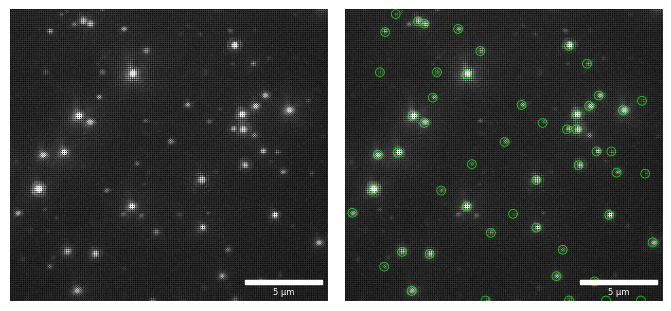

In [100]:
fig, axs = plotter.two_column_plot(ncols=2, width_ratios=[1, 1])
vmin, vmax = np.percentile(np.log10(summed), [0.1, 99.8])

xmin = 300
xmax = 600
ymin = 200
ymax = 500
axs[0], _ = plotter.image_plot(axs[0], np.log10(summed[xmin:xmax, ymin:ymax]), vmin=vmin, vmax=vmax, origin='upper', scalebar=True,
                              scalebarsize=5000, scalebarlabel='5 μm')

axs[1], _ = plotter.image_plot(axs[1], np.log10(summed[xmin:xmax, ymin:ymax]), vmin=vmin, vmax=vmax, origin='upper', scalebar=True,
                              scalebarsize=5000, scalebarlabel='5 μm')

detectedy = detected[:, 1][(detected[:, 1] > ymin) & (detected[:, 1] < ymax) & (detected[:, 0] > xmin) & (detected[:, 0] < xmax)]
detectedy = detectedy - ymin
detectedx = detected[:, 0][(detected[:, 1] > ymin) & (detected[:, 1] < ymax) & (detected[:, 0] > xmin) & (detected[:, 0] < xmax)]
detectedx = detectedx - xmin

axs[1].scatter(detectedy, detectedx, s=40, marker='o', color='lime', facecolor="None", linewidths=0.5)

plotter.save_or_show(fig, save_path=str(FIGURE_DIR / 'raw_data_and_detected_puncta.svg'), show=True)

### Figure 2 — example puncta: raw / weights / fit / residual / spectrum

Rather than re-fitting, pick `N_PUNCTA` individual single-frame localisations directly
from the existing per-frame fit results (`{folder_name}_MMStack_{POSITION}.h5`, produced
by the production fitting pipeline), then re-render everything downstream straight from
the raw data: crop the actual raw frame each fit came from, recompute the photoelectron
conversion and fitting weights, and reconstruct the fitted PSF model from the stored fit
parameters (Gaussian + Bayer mask, using the stored `A_*`/`bg_*` fractions de-normalised
by `photons`/`background_photons` back to absolute units).

In [16]:
# ── Load existing per-frame fits and pick N_PUNCTA single-frame localisations ──
H5_FILE = os.path.join(DATA_DIR, f"{folder_name}_MMStack_{POSITION}.h5")
fits_df = pd.read_hdf(H5_FILE, key='data')
print(f'{len(fits_df)} single-frame localisations in {Path(H5_FILE).name}')

margin = ROI_SIZE / 2
valid_fits = fits_df[
    (fits_df['xc'] > margin) & (fits_df['xc'] < width - margin) &
    (fits_df['yc'] > margin) & (fits_df['yc'] < height - margin)
    & (fits_df['chi_sqr'] < 2) & (fits_df['photons']/fits_df['background_photons'] < 100)
    & (fits_df['photons']/fits_df['background_photons'] > 90)
].reset_index(drop=True)
print(f'{len(valid_fits)}/{len(fits_df)} have a full {ROI_SIZE}x{ROI_SIZE} ROI available')

masks_stacked = M_F.get_stacked_masks(0, 0, width, height, SupRes_F.mosaic_unit)
smoothing_function = types.SimpleNamespace(
    args={'sigma': 1.5}, extent=1.5, smoothing_function=sCMOS.gaussian_filter_stack, data_arg='image',
)

rng = np.random.default_rng(SELECTION_SEED)
chosen_rows = valid_fits.iloc[rng.choice(len(valid_fits), size=N_PUNCTA, replace=False)].reset_index(drop=True)

puncta_all, weights_all, masks_all, coords_all, rows_all = [], [], [], [], []
for _, row in chosen_rows.iterrows():
    xcentre, ycentre = int(round(row['xc'])), int(round(row['yc']))
    xmin, xmax, ymin, ymax = SupRes_F.helper.calculate_roi_bounds(xcentre, ycentre, ROI_SIZE, width, height)

    frame_raw = IO.read_tiff(FILE, dtype='float32', frame=int(row['frame']))
    raw_roi = frame_raw[ymin:ymax, xmin:xmax]
    pe_roi = IO.convert_to_photoelectrons(
        raw_roi, gain_map=gain_c[ymin:ymax, xmin:xmax], offset_map=offset_c[ymin:ymax, xmin:xmax],
        rqe=rqe_c[ymin:ymax, xmin:xmax],
    )
    smoothed_roi = IO.apply_smoothing(pe_roi, smoothing_function, dtype='float32')
    weights_roi = IO.generate_weights(smoothed_roi, read_noise=readnoise_c[ymin:ymax, xmin:xmax], dtype='float32')
    mask_roi = masks_stacked[ymin:ymax, xmin:xmax, :]

    puncta_all.append(pe_roi)
    weights_all.append(weights_roi)
    masks_all.append(mask_roi)
    coords_all.append((xmin, ymin))
    rows_all.append(row)

66059 single-frame localisations in 500pM525_100pM585_100pM605_25pM655_100pM705_25pM800_514DC_515LP_30p515_1_1_MMStack_4-Pos000_001.h5
2174/66059 have a full 12x12 ROI available


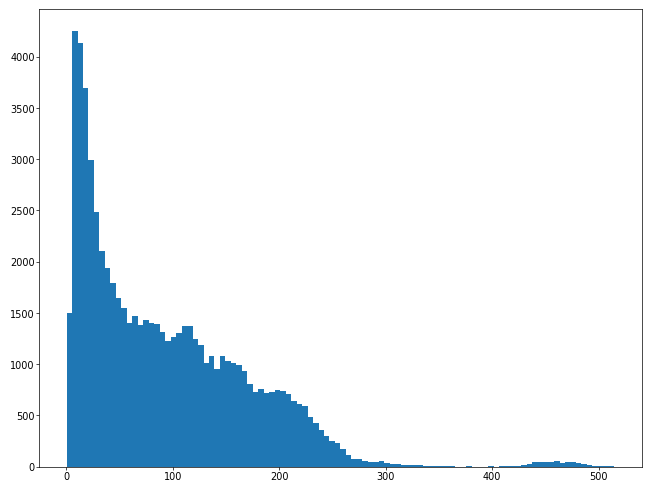

In [12]:
plt.hist(fits_df['photons']/fits_df['background_photons'], 100);
plt.show()

In [17]:
# ── Reconstruct the fitted PSF model + residual for each chosen punctum ────────
# Mask/h5 channel order is B, G, R (np.unique(mosaic_unit), alphabetical). The h5's
# A_*/bg_* columns are normalised fractions (sum to 1); de-normalise back to absolute
# photon-like units using each row's own 'photons'/'background_photons' totals.
x_arr = np.arange(ROI_SIZE, dtype=np.float32)
models, residuals, spectra, xy_local, frame_labels = {}, {}, {}, {}, {}

for k, row in enumerate(rows_all):
    xmin, ymin = coords_all[k]
    xc_local, yc_local = row['xc'] - xmin, row['yc'] - ymin
    s_x, s_y = row['s_x'], row['s_y']

    A_frac = np.array([row['A_B'], row['A_G'], row['A_R']])
    bg_frac = np.array([row['bg_B'], row['bg_G'], row['bg_R']])
    A_abs = A_frac * row['photons']
    bg_abs = bg_frac * row['background_photons']

    gauss2d = np.zeros((ROI_SIZE, ROI_SIZE), dtype=np.float32)
    gauss2d = gaussoptfuncs.gaussian_unscaled_model(gauss2d, x_arr, ROI_SIZE, xc_local, yc_local, s_x, s_y)

    model = np.zeros((ROI_SIZE, ROI_SIZE), dtype=np.float32)
    mask_roi = masks_all[k]
    for c in range(3):
        m = mask_roi[:, :, c]
        model[m] = A_abs[c] * gauss2d[m] + bg_abs[c]

    models[k]       = model
    residuals[k]     = puncta_all[k] - model
    spectra[k]       = A_frac
    xy_local[k]      = (xc_local, yc_local)
    frame_labels[k]  = int(row['frame'])

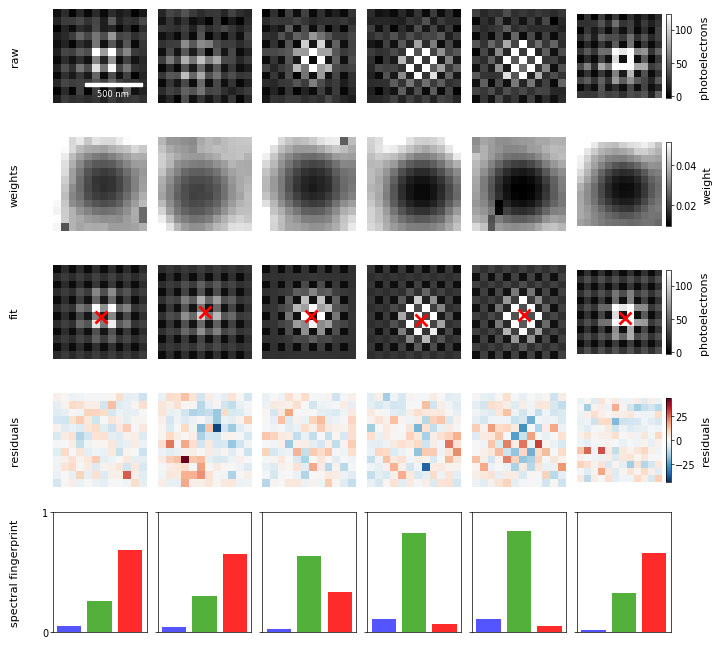

In [43]:
channel_colours = ["#5555ff", "#53b03b", "#ff2a2a"]  # B, G, R -- matches Ternary_Plot_SingleMolecules.ipynb
row_labels = ['raw', 'weights', 'fit', 'residuals', 'spectral fingerprint']

fig, axs = plotter.two_column_plot(nrows=5, ncols=N_PUNCTA, width=6.69, height=6.5)

vmin = np.percentile(puncta_all, 0.1)
vmax = np.percentile(puncta_all, 97)

vmin_weights = np.percentile(weights_all, 0.1)
vmax_weights = np.percentile(weights_all, 97)

rmaxes = np.zeros(N_PUNCTA)
for k in range(N_PUNCTA):
    rmaxes[k] = np.max(np.abs(residuals[k]))
rmax = np.max(rmaxes)

for k in range(N_PUNCTA):
    col = k
    raw_roi = puncta_all[k]
    xc_local, yc_local = xy_local[k]

    axs[0, col], _ = plotter.image_plot(
        axs[0, col], raw_roi, vmin=vmin, vmax=vmax, origin='upper',
        scalebar=(col == 0), scalebarsize=500.0, scalebarlabel='500 nm',
        colorbar=(col == 5), colorbar_label='photoelectrons'
    )
    
    axs[1, col], _ = plotter.image_plot(axs[1, col], 
                                        weights_all[k], vmin=vmin_weights, vmax=vmax_weights, cmap='gray', origin='upper',
                                        colorbar=(col == 5), colorbar_label='weight'
                      )
    axs[1, col].set_xticks([]); axs[1, col].set_yticks([])

    axs[2, col], _ = plotter.image_plot(axs[2, col], models[k], vmin=vmin, vmax=vmax, origin='upper', 
                                        colorbar=(col == 5), colorbar_label='photoelectrons')
    axs[2, col].plot(xc_local, yc_local, 'rx', markersize=8, markeredgewidth=2)

    axs[3, col], _ = plotter.image_plot(axs[3, col], residuals[k], cmap='RdBu_r', vmin=-rmax, vmax=rmax, origin='upper',
                                       colorbar=(col == 5), colorbar_label='residuals')
    axs[3, col].set_xticks([]); axs[3, col].set_yticks([])

    axs[4, col].bar(np.arange(3), spectra[k], color=channel_colours)
    axs[4, col].set_ylim([0, 1]); axs[4, col].set_xticks([]); axs[4, col].set_yticks([0, 1])
    if col != 0:
        axs[4, col].set_yticklabels('')
    axs[4, col].grid(False)


for row in range(5):
    axs[row, 0].text(-0.35, 0.5, row_labels[row], transform=axs[row, 0].transAxes,
                      fontsize=8, ha='right', va='center', rotation=90)

plotter.save_or_show(fig, save_path=str(FIGURE_DIR / 'example_puncta_raw_weights_fit_residual_spectrum.svg'), show=True)

In [32]:
residuals

{0: array([[  2.17968059e+00,   8.95040512e-01,  -2.70682240e+00,
          -1.69940758e+00,  -7.60350585e-01,  -1.00878525e+00,
          -4.60664034e-01,   6.56557083e-01,   7.63936710e+00,
          -3.82327843e+00,  -3.21998763e+00,  -9.03345966e+00],
        [ -4.18971443e+00,   1.36917877e+00,   8.79804039e+00,
           6.85391617e+00,   3.02397537e+00,   2.43114281e+00,
          -8.26101685e+00,   1.31338081e+01,  -5.40650749e+00,
          -3.45301628e+00,   1.09135628e+00,   6.89966965e+00],
        [ -5.38388157e+00,  -3.61778831e+00,   4.66446161e-01,
          -1.12569427e+00,   9.79541874e+00,   9.28177643e+00,
           7.74673510e+00,  -7.80423641e+00,  -2.15022111e+00,
          -4.14854145e+00,  -3.66889238e+00,   3.33194733e-01],
        [ -7.36513996e+00,  -8.41447258e+00,   6.78255272e+00,
           1.11735497e+01,   4.58631706e+00,  -8.83361053e+00,
          -1.40800476e-01,   5.16812134e+00,   2.16341782e+00,
          -4.30393600e+00,   1.23526192e+00,   1.